<a href="https://colab.research.google.com/github/Abhishaan/abhijeet/blob/main/Cyclone_Alert_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap, MarkerCluster
import warnings
warnings.filterwarnings('ignore')

# Set style for matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

In [ ]:
df = pd.read_csv('/content/ibtracs.last3years.list.v04r01.csv')
display(df.head())

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES,WMO_AGENCY,TRACK_TYPE,DIST2LAND,LANDFALL,IFLAG,USA_AGENCY,USA_ATCF_ID,USA_LAT,USA_LON,USA_RECORD,USA_STATUS,USA_WIND,USA_PRES,...,TD9635_WIND,TD9635_PRES,TD9635_ROCI,NEUMANN_LAT,NEUMANN_LON,NEUMANN_CLASS,NEUMANN_WIND,NEUMANN_PRES,MLC_LAT,MLC_LON,MLC_CLASS,MLC_WIND,MLC_PRES,USA_GUST,BOM_GUST,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
0,,Year,,,,,,,degrees_north,degrees_east,kts,mb,,,km,km,,,,degrees_north,degrees_east,,,kts,mb,...,kts,mb,nmile,degrees_north,degrees_east,,kts,mb,degrees_north,degrees_east,,kts,mb,kts,kts,second,kts,second,ft,nmile,nmile,nmile,nmile,kts,degrees
1,2022008S13148,2022,1,SP,EA,TIFFANY,2022-01-08 00:00:00,MX,-12.6,147.7,25,1005,bom,main,270,270,O______O_______,jtwc_sh,SH062022,-13.3,147.9,,DB,20,1007,...,,,,,,,,,,,,,,,45,45,,,,,,,,6,160
2,2022008S13148,2022,1,SP,EA,TIFFANY,2022-01-08 03:00:00,MX,-12.9,147.8,,,,main,303,303,P______P_______,,SH062022,-13.4,148.0,,DB,20,1007,...,,,,,,,,,,,,,,,,,,,,,,,,5,160
3,2022008S13148,2022,1,SP,EA,TIFFANY,2022-01-08 06:00:00,MX,-13.1,147.9,25,1004,bom,main,324,324,O______O_______,jtwc_sh,SH062022,-13.4,148.0,,DB,20,1007,...,,,,,,,,,,,,,,,45,45,,,,,,,,4,160
4,2022008S13148,2022,1,SP,EA,TIFFANY,2022-01-08 09:00:00,MX,-13.2,147.9,,,,main,336,335,P______P_______,,SH062022,-13.4,148.0,,DB,23,1006,...,,,,,,,,,,,,,,,,,,,,,,,,2,165


In [ ]:
df_raw = pd.read_csv('/content/ibtracs.last3years.list.v04r01.csv',header=0)

print("=" * 60)
print("📊 RAW DATA OVERVIEW")
print("=" * 60)
print(f"\n🔹 Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"🔹 Memory Usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display first few rows
print("\n📋 First 5 rows:")
df_raw.head()

📊 RAW DATA OVERVIEW

🔹 Shape: 23265 rows × 174 columns
🔹 Memory Usage: 192.29 MB

📋 First 5 rows:


,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES,WMO_AGENCY,TRACK_TYPE,DIST2LAND,LANDFALL,IFLAG,USA_AGENCY,USA_ATCF_ID,USA_LAT,USA_LON,USA_RECORD,USA_STATUS,USA_WIND,USA_PRES,...,TD9635_WIND,TD9635_PRES,TD9635_ROCI,NEUMANN_LAT,NEUMANN_LON,NEUMANN_CLASS,NEUMANN_WIND,NEUMANN_PRES,MLC_LAT,MLC_LON,MLC_CLASS,MLC_WIND,MLC_PRES,USA_GUST,BOM_GUST,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
0,,Year,,,,,,,degrees_north,degrees_east,kts,mb,,,km,km,,,,degrees_north,degrees_east,,,kts,mb,...,kts,mb,nmile,degrees_north,degrees_east,,kts,mb,degrees_north,degrees_east,,kts,mb,kts,kts,second,kts,second,ft,nmile,nmile,nmile,nmile,kts,degrees
1,2022008S13148,2022,1,SP,EA,TIFFANY,2022-01-08 00:00:00,MX,-12.6,147.7,25,1005,bom,main,270,270,O______O_______,jtwc_sh,SH062022,-13.3,147.9,,DB,20,1007,...,,,,,,,,,,,,,,,45,45,,,,,,,,6,160
2,2022008S13148,2022,1,SP,EA,TIFFANY,2022-01-08 03:00:00,MX,-12.9,147.8,,,,main,303,303,P______P_______,,SH062022,-13.4,148.0,,DB,20,1007,...,,,,,,,,,,,,,,,,,,,,,,,,5,160
3,2022008S13148,2022,1,SP,EA,TIFFANY,2022-01-08 06:00:00,MX,-13.1,147.9,25,1004,bom,main,324,324,O______O_______,jtwc_sh,SH062022,-13.4,148.0,,DB,20,1007,...,,,,,,,,,,,,,,,45,45,,,,,,,,4,160
4,2022008S13148,2022,1,SP,EA,TIFFANY,2022-01-08 09:00:00,MX,-13.2,147.9,,,,main,336,335,P______P_______,,SH062022,-13.4,148.0,,DB,23,1006,...,,,,,,,,,,,,,,,,,,,,,,,,2,165


In [ ]:
col_info = pd.DataFrame({
    'Column': df_raw.columns,
    'Non-Null Count': df_raw.notna().sum().values,
    'Null Count': df_raw.isna().sum().values,
    'Null %': (df_raw.isna().sum().values / len(df_raw) * 100).round(2),
    'Dtype': df_raw.dtypes.values,
    'Sample Value': [df_raw[col].dropna().iloc[0] if df_raw[col].notna().any() else 'N/A' for col in df_raw.columns]
})


useful_cols = col_info[col_info['Null %'] < 50]
print(f"\n🔹 Total Columns: {len(df_raw.columns)}")
print(f"🔹 Useful Columns (< 50% null): {len(useful_cols)}")

useful_cols.head(30)


🔹 Total Columns: 174
🔹 Useful Columns (< 50% null): 174


,Column,Non-Null Count,Null Count,Null %,Dtype,Sample Value
0,SID,23265,0,0.00,object,
1,SEASON,23265,0,0.00,object,Year
2,NUMBER,23265,0,0.00,object,
3,BASIN,19157,4108,17.66,object,
4,SUBBASIN,19972,3293,14.15,object,
5,NAME,23265,0,0.00,object,
6,ISO_TIME,23265,0,0.00,object,
7,NATURE,23265,0,0.00,object,
8,LAT,23265,0,0.00,object,degrees_north
9,LON,23265,0,0.00,object,degrees_east


In [ ]:

# DATA CLEANING


selected_columns = [
    # Identifiers
    'SID', 'NAME', 'SEASON', 'BASIN', 'SUBBASIN',

    # Time
    'ISO_TIME',

    # Position
    'LAT', 'LON',

    # Intensity - WMO (World Meteorological Organization)
    'WMO_WIND', 'WMO_PRES', 'WMO_AGENCY',

    # Intensity - USA
    'USA_WIND', 'USA_PRES', 'USA_SSHS', 'USA_STATUS',

    # Nature of storm
    'NATURE',

    # Track info
    'TRACK_TYPE', 'LANDFALL',
    'STORM_SPEED', 'STORM_DIR',
    'USA_R34_NE', 'USA_R34_SE', 'USA_R34_SW', 'USA_R34_NW',
    'USA_R50_NE', 'USA_R50_SE', 'USA_R50_SW', 'USA_R50_NW',
    'USA_RMW', 'USA_EYE'
]

available_cols = [col for col in selected_columns if col in df_raw.columns]
df = df_raw[available_cols].copy()

print(f" Selected {len(available_cols)} relevant columns")

df = df[~df['SID'].astype(str).str.contains('degrees|nmile|kts|mb|Year', na=False)]
df = df[df['SID'].notna()]

print(f"Removed metadata rows. Remaining: {len(df)} rows")


df['ISO_TIME'] = pd.to_datetime(df['ISO_TIME'], errors='coerce')


numeric_cols = ['LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'USA_WIND', 'USA_PRES',
                'USA_SSHS', 'STORM_SPEED', 'STORM_DIR', 'SEASON', 'LANDFALL',
                'USA_R34_NE', 'USA_R34_SE', 'USA_R34_SW', 'USA_R34_NW',
                'USA_R50_NE', 'USA_R50_SE', 'USA_R50_SW', 'USA_R50_NW',
                'USA_RMW', 'USA_EYE']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f" Converted data types")


df['WIND'] = df['WMO_WIND'].fillna(df['USA_WIND'])
df['PRESSURE'] = df['WMO_PRES'].fillna(df['USA_PRES'])

print(f"Created unified WIND and PRESSURE columns")


critical_cols = ['LAT', 'LON', 'ISO_TIME']
df_before = len(df)
df = df.dropna(subset=critical_cols)
print(f"Dropped {df_before - len(df)} rows with missing critical values")


df = df[(df['LAT'] >= -90) & (df['LAT'] <= 90)]
df = df[(df['LON'] >= -180) & (df['LON'] <= 180)]

print(f"Validated coordinates")


df = df.sort_values(['SID', 'ISO_TIME']).reset_index(drop=True)

print(f"Sorted data by storm ID and time")

print("\n" + "=" * 60)
print("📊 CLEANED DATA SUMMARY")
print("=" * 60)
print(f"Final Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Unique Storms: {df['SID'].nunique()}")
print(f"Date Range: {df['ISO_TIME'].min()} to {df['ISO_TIME'].max()}")
print(f"Basins: {df['BASIN'].unique()}")

df.head(10)


 Selected 30 relevant columns
Removed metadata rows. Remaining: 23265 rows
 Converted data types
Created unified WIND and PRESSURE columns
Dropped 1 rows with missing critical values
Validated coordinates
Sorted data by storm ID and time

📊 CLEANED DATA SUMMARY
Final Shape: 22891 rows × 32 columns
Unique Storms: 409
Date Range: 2022-01-07 12:00:00 to 2025-12-03 00:00:00
Basins: ['SP' 'SI' 'NI' 'WP' 'EP' nan]


,SID,NAME,SEASON,BASIN,SUBBASIN,ISO_TIME,LAT,LON,WMO_WIND,WMO_PRES,WMO_AGENCY,USA_WIND,USA_PRES,USA_SSHS,USA_STATUS,NATURE,TRACK_TYPE,LANDFALL,STORM_SPEED,STORM_DIR,USA_R34_NE,USA_R34_SE,USA_R34_SW,USA_R34_NW,USA_R50_NE,USA_R50_SE,USA_R50_SW,USA_R50_NW,USA_RMW,USA_EYE,WIND,PRESSURE
0,2022008S13148,TIFFANY,2022.0,SP,EA,2022-01-08 00:00:00,-12.6,147.7,25.0,1005.0,bom,20.0,1007.0,-3,DB,MX,main,270.0,6.0,160.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,1005.0
1,2022008S13148,TIFFANY,2022.0,SP,EA,2022-01-08 03:00:00,-12.9,147.8,NaN,NaN,,20.0,1007.0,-3,DB,MX,main,303.0,5.0,160.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0,1007.0
2,2022008S13148,TIFFANY,2022.0,SP,EA,2022-01-08 06:00:00,-13.1,147.9,25.0,1004.0,bom,20.0,1007.0,-3,DB,MX,main,324.0,4.0,160.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.0,1004.0
3,2022008S13148,TIFFANY,2022.0,SP,EA,2022-01-08 09:00:00,-13.2,147.9,NaN,NaN,,23.0,1006.0,-3,DB,MX,main,335.0,2.0,165.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.0,1006.0
4,2022008S13148,TIFFANY,2022.0,SP,EA,2022-01-08 12:00:00,-13.3,148.0,30.0,1004.0,bom,25.0,1004.0,-1,TD,TS,main,336.0,3.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,1004.0
5,2022008S13148,TIFFANY,2022.0,SP,EA,2022-01-08 15:00:00,-13.5,148.0,NaN,NaN,,28.0,1003.0,-1,TD,TS,main,315.0,4.0,195.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,1003.0
6,2022008S13148,TIFFANY,2022.0,SP,EA,2022-01-08 18:00:00,-13.7,147.9,30.0,1002.0,bom,30.0,1001.0,-1,TD,TS,main,281.0,5.0,230.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.0,NaN,30.0,1002.0
7,2022008S13148,TIFFANY,2022.0,SP,EA,2022-01-08 21:00:00,-13.8,147.5,NaN,NaN,,33.0,1000.0,-1,TD,TS,main,238.0,7.0,250.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.0,NaN,33.0,1000.0
8,2022008S13148,TIFFANY,2022.0,SP,EA,2022-01-09 00:00:00,-14.0,147.2,30.0,1000.0,bom,35.0,998.0,0,TS,TS,main,214.0,5.0,250.0,10.0,15.0,60.0,45.0,NaN,NaN,NaN,NaN,45.0,NaN,30.0,1000.0
9,2022008S13148,TIFFANY,2022.0,SP,EA,2022-01-09 03:00:00,-14.0,147.0,NaN,NaN,,40.0,997.0,0,TS,TS,main,190.0,4.0,255.0,15.0,20.0,70.0,58.0,NaN,NaN,NaN,NaN,35.0,NaN,40.0,997.0


In [ ]:

#  FEATURE ENGINEERING

df['YEAR'] = df['ISO_TIME'].dt.year
df['MONTH'] = df['ISO_TIME'].dt.month
df['DAY'] = df['ISO_TIME'].dt.day
df['HOUR'] = df['ISO_TIME'].dt.hour
df['DAY_OF_YEAR'] = df['ISO_TIME'].dt.dayofyear
df['WEEK_OF_YEAR'] = df['ISO_TIME'].dt.isocalendar().week.astype(int)

print("Created time-based features: YEAR, MONTH, DAY, HOUR, DAY_OF_YEAR, WEEK_OF_YEAR")

def categorize_cyclone(wind):
    if pd.isna(wind):
        return 'Unknown'
    elif wind < 34:
        return 'Tropical Depression'
    elif wind < 64:
        return 'Tropical Storm'
    elif wind < 83:
        return 'Category 1'
    elif wind < 96:
        return 'Category 2'
    elif wind < 113:
        return 'Category 3'
    elif wind < 137:
        return 'Category 4'
    else:
        return 'Category 5'

df['CATEGORY'] = df['WIND'].apply(categorize_cyclone)

category_map = {
    'Tropical Depression': 0, 'Tropical Storm': 1, 'Category 1': 2,
    'Category 2': 3, 'Category 3': 4, 'Category 4': 5, 'Category 5': 6, 'Unknown': -1
}
df['CATEGORY_NUM'] = df['CATEGORY'].map(category_map)

print(" Created CATEGORY and CATEGORY_NUM features")

df['IS_TROPICAL_STORM'] = (df['WIND'] >= 34).astype(int)
df['IS_HURRICANE'] = (df['WIND'] >= 64).astype(int)
df['IS_MAJOR_HURRICANE'] = (df['WIND'] >= 96).astype(int)

print("Created binary target variables: IS_TROPICAL_STORM, IS_HURRICANE, IS_MAJOR_HURRICANE")

df['BASIN_ENCODED'] = df['BASIN'].astype('category').cat.codes

basin_mapping = dict(zip(df['BASIN'].astype('category').cat.categories,
                         range(len(df['BASIN'].astype('category').cat.categories))))
print(f"Basin Encoding: {basin_mapping}")

df['LAT_CHANGE'] = df.groupby('SID')['LAT'].diff()
df['LON_CHANGE'] = df.groupby('SID')['LON'].diff()
df['WIND_CHANGE'] = df.groupby('SID')['WIND'].diff()
df['PRESSURE_CHANGE'] = df.groupby('SID')['PRESSURE'].diff()

print("Created change features: LAT_CHANGE, LON_CHANGE, WIND_CHANGE, PRESSURE_CHANGE")

df['HOURS_SINCE_START'] = df.groupby('SID')['ISO_TIME'].transform(
    lambda x: (x - x.min()).dt.total_seconds() / 3600
)

print("Created HOURS_SINCE_START feature")

df['WIND_ROLLING_3'] = df.groupby('SID')['WIND'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)
df['PRESSURE_ROLLING_3'] = df.groupby('SID')['PRESSURE'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

print("Created rolling average features")

df['HEMISPHERE'] = np.where(df['LAT'] >= 0, 'Northern', 'Southern')
df['HEMISPHERE_ENCODED'] = np.where(df['LAT'] >= 0, 1, 0)

print("Created HEMISPHERE feature")


def get_season(row):
    month = row['MONTH']
    hemisphere = row['HEMISPHERE']

    if hemisphere == 'Northern':
        if month in [12, 1, 2]:
            return 'Winter'
        elif month in [3, 4, 5]:
            return 'Spring'
        elif month in [6, 7, 8]:
            return 'Summer'
        else:
            return 'Fall'
    else:
        if month in [12, 1, 2]:
            return 'Summer'
        elif month in [3, 4, 5]:
            return 'Fall'
        elif month in [6, 7, 8]:
            return 'Winter'
        else:
            return 'Spring'

df['METEOROLOGICAL_SEASON'] = df.apply(get_season, axis=1)

print(" Created METEOROLOGICAL_SEASON feature")

print(f" Total Features: {len(df.columns)}")
print(f" New Features Added: {len(df.columns) - len(available_cols)}")

# Display feature info
print("\n📋 Feature List:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")


Created time-based features: YEAR, MONTH, DAY, HOUR, DAY_OF_YEAR, WEEK_OF_YEAR
 Created CATEGORY and CATEGORY_NUM features
Created binary target variables: IS_TROPICAL_STORM, IS_HURRICANE, IS_MAJOR_HURRICANE
Basin Encoding: {'EP': 0, 'NI': 1, 'SI': 2, 'SP': 3, 'WP': 4}
Created change features: LAT_CHANGE, LON_CHANGE, WIND_CHANGE, PRESSURE_CHANGE
Created HOURS_SINCE_START feature
Created rolling average features
Created HEMISPHERE feature
 Created METEOROLOGICAL_SEASON feature
 Total Features: 54
 New Features Added: 24

📋 Feature List:
   1. SID
   2. NAME
   3. SEASON
   4. BASIN
   5. SUBBASIN
   6. ISO_TIME
   7. LAT
   8. LON
   9. WMO_WIND
  10. WMO_PRES
  11. WMO_AGENCY
  12. USA_WIND
  13. USA_PRES
  14. USA_SSHS
  15. USA_STATUS
  16. NATURE
  17. TRACK_TYPE
  18. LANDFALL
  19. STORM_SPEED
  20. STORM_DIR
  21. USA_R34_NE
  22. USA_R34_SE
  23. USA_R34_SW
  24. USA_R34_NW
  25. USA_R50_NE
  26. USA_R50_SE
  27. USA_R50_SW
  28. USA_R50_NW
  29. USA_RMW
  30. USA_EYE
  31. WIND

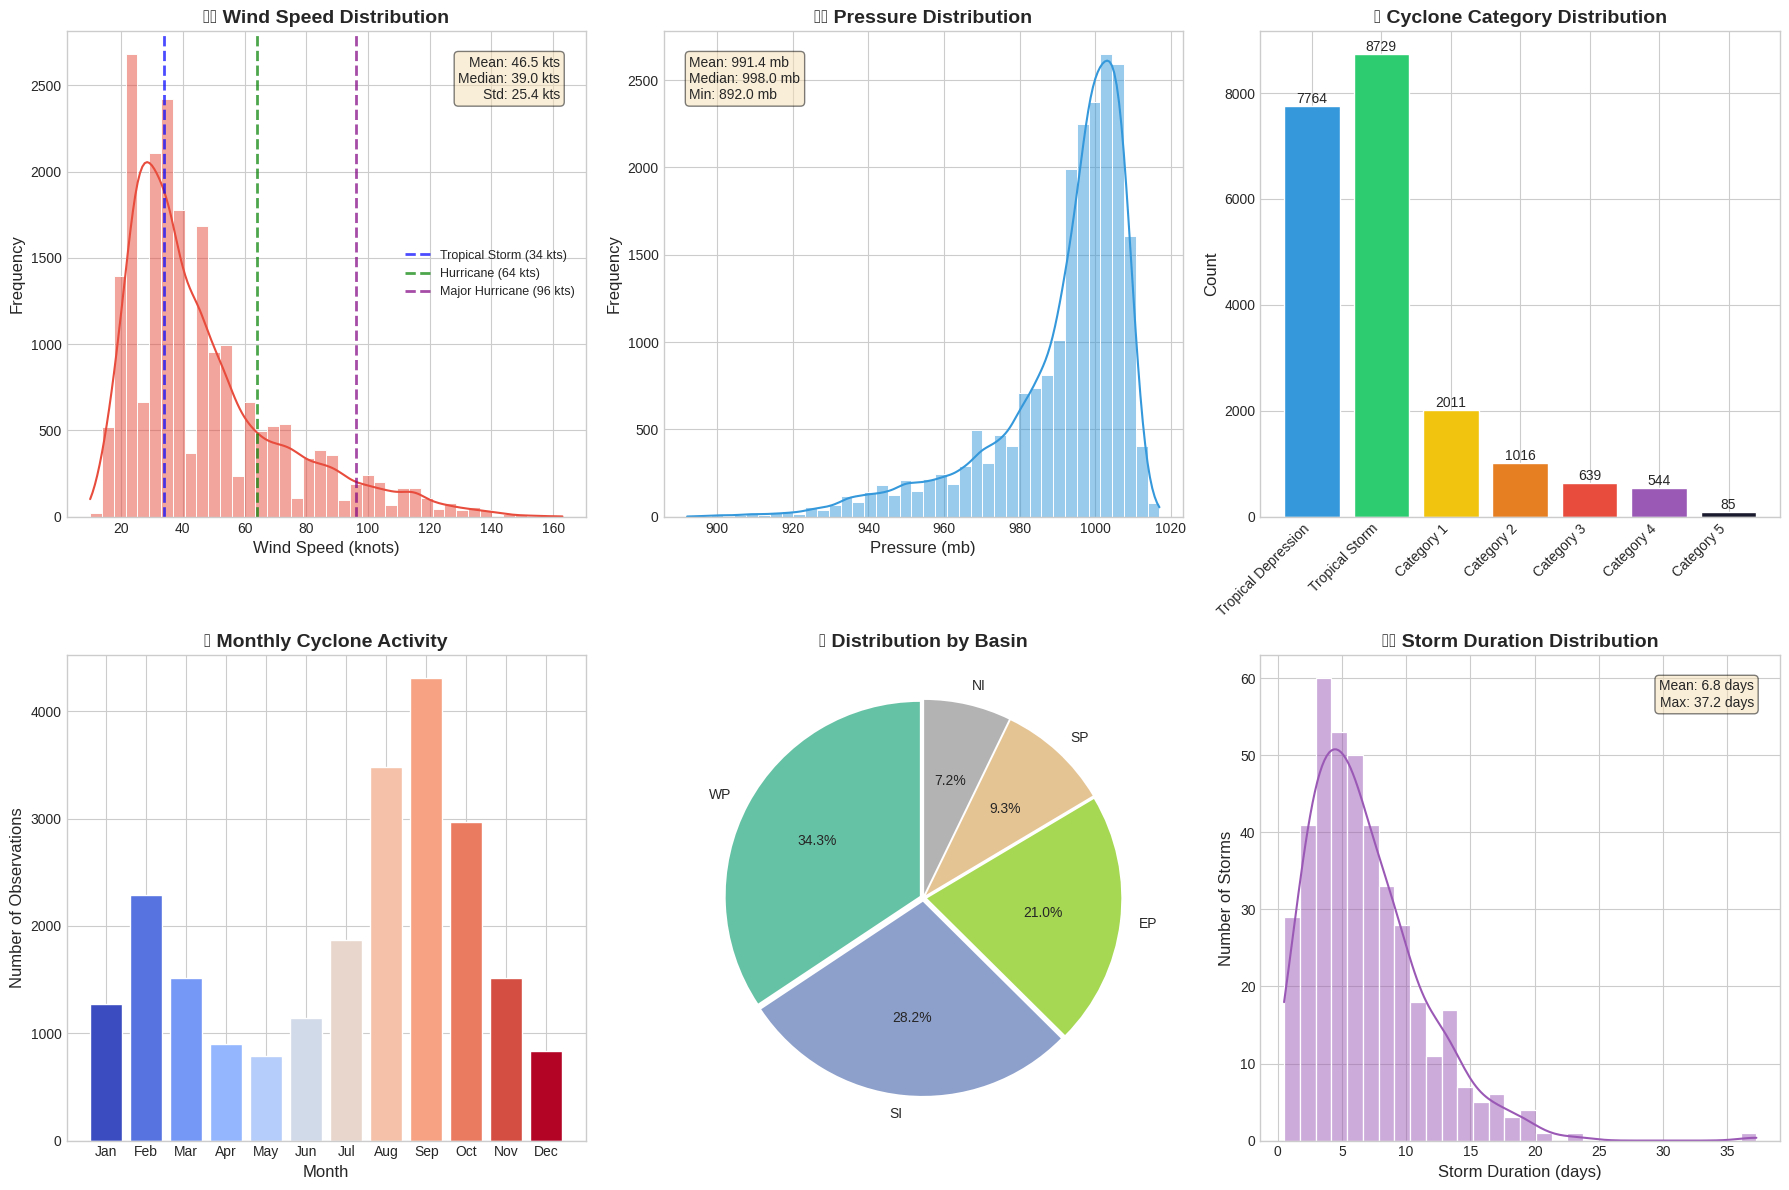

✅ Distribution Analysis saved as 'distribution_analysis.png'


In [ ]:


fig, axes = plt.subplots(2, 3, figsize=(18, 12))


ax1 = axes[0, 0]
wind_data = df['WIND'].dropna()
sns.histplot(wind_data, bins=40, kde=True, color='#e74c3c', ax=ax1, edgecolor='white')
ax1.axvline(34, color='blue', linestyle='--', linewidth=2, alpha=0.7, label='Tropical Storm (34 kts)')
ax1.axvline(64, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Hurricane (64 kts)')
ax1.axvline(96, color='purple', linestyle='--', linewidth=2, alpha=0.7, label='Major Hurricane (96 kts)')
ax1.set_xlabel('Wind Speed (knots)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('🌪️ Wind Speed Distribution', fontsize=14, fontweight='bold')
ax1.legend(fontsize=9)


stats_text = f'Mean: {wind_data.mean():.1f} kts\nMedian: {wind_data.median():.1f} kts\nStd: {wind_data.std():.1f} kts'
ax1.text(0.95, 0.95, stats_text, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Pressure Distribution
ax2 = axes[0, 1]
pressure_data = df['PRESSURE'].dropna()
sns.histplot(pressure_data, bins=40, kde=True, color='#3498db', ax=ax2, edgecolor='white')
ax2.set_xlabel('Pressure (mb)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('🌡️ Pressure Distribution', fontsize=14, fontweight='bold')

stats_text = f'Mean: {pressure_data.mean():.1f} mb\nMedian: {pressure_data.median():.1f} mb\nMin: {pressure_data.min():.1f} mb'
ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


ax3 = axes[0, 2]
category_order = ['Tropical Depression', 'Tropical Storm', 'Category 1', 'Category 2',
                  'Category 3', 'Category 4', 'Category 5']
category_counts = df['CATEGORY'].value_counts()
category_counts = category_counts.reindex([c for c in category_order if c in category_counts.index])
colors = ['#3498db', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6', '#1a1a2e']
bars = ax3.bar(range(len(category_counts)), category_counts.values, color=colors[:len(category_counts)], edgecolor='white')
ax3.set_xticks(range(len(category_counts)))
ax3.set_xticklabels(category_counts.index, rotation=45, ha='right')
ax3.set_ylabel('Count', fontsize=12)
ax3.set_title('🌀 Cyclone Category Distribution', fontsize=14, fontweight='bold')


for bar, val in zip(bars, category_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}', ha='center', va='bottom', fontsize=10)


ax4 = axes[1, 0]
monthly_counts = df.groupby('MONTH').size()
colors = plt.cm.coolwarm(np.linspace(0, 1, 12))
bars = ax4.bar(monthly_counts.index, monthly_counts.values, color=colors, edgecolor='white')
ax4.set_xlabel('Month', fontsize=12)
ax4.set_ylabel('Number of Observations', fontsize=12)
ax4.set_title('📅 Monthly Cyclone Activity', fontsize=14, fontweight='bold')
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])


ax5 = axes[1, 1]
basin_counts = df['BASIN'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(basin_counts)))
wedges, texts, autotexts = ax5.pie(basin_counts.values, labels=basin_counts.index,
                                    autopct='%1.1f%%', colors=colors,
                                    explode=[0.02]*len(basin_counts),
                                    startangle=90)
ax5.set_title('🌍 Distribution by Basin', fontsize=14, fontweight='bold')


ax6 = axes[1, 2]
storm_duration = df.groupby('SID')['HOURS_SINCE_START'].max()
sns.histplot(storm_duration / 24, bins=30, kde=True, color='#9b59b6', ax=ax6, edgecolor='white')
ax6.set_xlabel('Storm Duration (days)', fontsize=12)
ax6.set_ylabel('Number of Storms', fontsize=12)
ax6.set_title('⏱️ Storm Duration Distribution', fontsize=14, fontweight='bold')

stats_text = f'Mean: {(storm_duration/24).mean():.1f} days\nMax: {(storm_duration/24).max():.1f} days'
ax6.text(0.95, 0.95, stats_text, transform=ax6.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Distribution Analysis saved as 'distribution_analysis.png'")


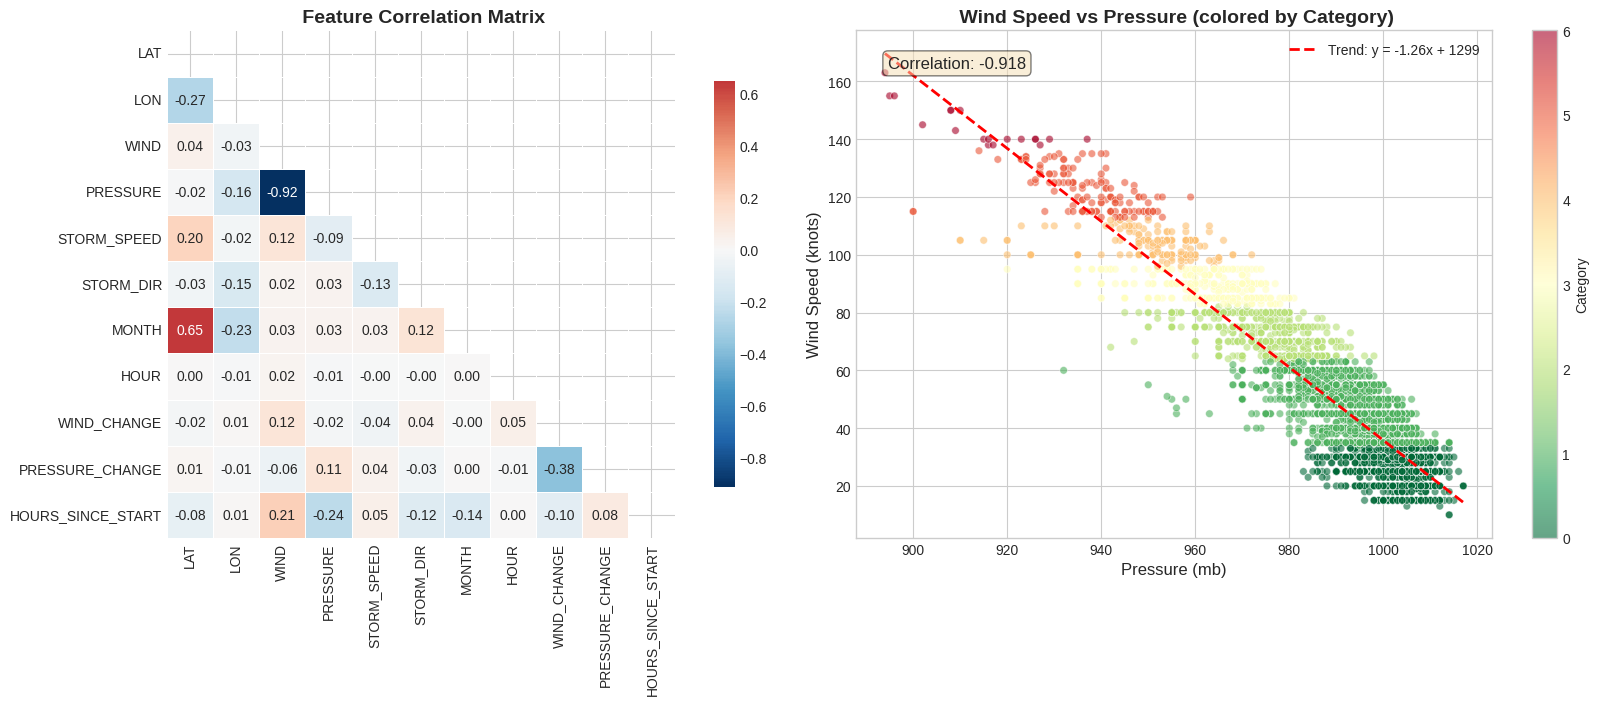

 Correlation Analysis saved as 'correlation_analysis.png'


In [ ]:

# CORRELATION ANALYSIS


fig, axes = plt.subplots(1, 2, figsize=(18, 7))


ax1 = axes[0]
corr_cols = ['LAT', 'LON', 'WIND', 'PRESSURE', 'STORM_SPEED', 'STORM_DIR',
             'MONTH', 'HOUR', 'WIND_CHANGE', 'PRESSURE_CHANGE', 'HOURS_SINCE_START']
corr_cols = [col for col in corr_cols if col in df.columns]
corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax1,
            cbar_kws={'shrink': 0.8})
ax1.set_title(' Feature Correlation Matrix', fontsize=14, fontweight='bold')


ax2 = axes[1]
sample_df = df.dropna(subset=['WIND', 'PRESSURE']).sample(min(5000, len(df)), random_state=42)
scatter = ax2.scatter(sample_df['PRESSURE'], sample_df['WIND'],
                       c=sample_df['CATEGORY_NUM'], cmap='RdYlGn_r',
                       alpha=0.6, s=30, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Pressure (mb)', fontsize=12)
ax2.set_ylabel('Wind Speed (knots)', fontsize=12)
ax2.set_title(' Wind Speed vs Pressure (colored by Category)', fontsize=14, fontweight='bold')


cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Category', fontsize=10)


z = np.polyfit(sample_df['PRESSURE'], sample_df['WIND'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample_df['PRESSURE'].min(), sample_df['PRESSURE'].max(), 100)
ax2.plot(x_line, p(x_line), "r--", linewidth=2, label=f'Trend: y = {z[0]:.2f}x + {z[1]:.0f}')
ax2.legend()


corr = sample_df['WIND'].corr(sample_df['PRESSURE'])
ax2.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax2.transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Correlation Analysis saved as 'correlation_analysis.png'")


In [ ]:
# Get unique storms
unique_storms = df['SID'].unique()
print(f"Total unique storms: {len(unique_storms)}")

# Select a few storms for visualization (to avoid overcrowding)
sample_storms = unique_storms[:min(10, len(unique_storms))]

# Create base map
center_lat = df['LAT'].mean()
center_lon = df['LON'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=4,
    tiles='CartoDB dark_matter'
)

# Color palette for storms
colors = ['red', 'blue', 'green', 'purple', 'orange', 'pink', 'cyan', 'yellow', 'lime', 'magenta']

# Add storm tracks
for i, storm_id in enumerate(sample_storms):
    storm_data = df[df['SID'] == storm_id].sort_values('ISO_TIME')
    storm_name = storm_data['NAME'].iloc[0] if pd.notna(storm_data['NAME'].iloc[0]) else storm_id
    color = colors[i % len(colors)]

    # Create track line
    points = list(zip(storm_data['LAT'], storm_data['LON']))

    if len(points) > 1:
        folium.PolyLine(
            points,
            weight=3,
            color=color,
            opacity=0.8,
            popup=f"<b>{storm_name}</b><br>ID: {storm_id}"
        ).add_to(m)

    # Add markers for each observation
    for _, row in storm_data.iterrows():
        # Size based on wind speed
        wind = row['WIND'] if pd.notna(row['WIND']) else 30
        radius = max(3, min(wind / 10, 15))

        popup_text = f"""
        <b>{storm_name}</b><br>
        Time: {row['ISO_TIME']}<br>
        Wind: {row['WIND']} kts<br>
        Pressure: {row['PRESSURE']} mb<br>
        Category: {row['CATEGORY']}
        """

        folium.CircleMarker(
            location=[row['LAT'], row['LON']],
            radius=radius,
            color=color,
            fill=True,
            fillOpacity=0.7,
            popup=folium.Popup(popup_text, max_width=200)
        ).add_to(m)

# Add legend
legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; background-color: white;
            padding: 10px; border-radius: 5px; border: 2px solid gray;">
    <p style="margin: 0; font-weight: bold;"> Storm Tracks</p>
    <p style="margin: 5px 0; font-size: 12px;">Circle size = Wind intensity</p>
    <p style="margin: 5px 0; font-size: 12px;">Colors = Different storms</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Save and display
m.save('storm_tracks_interactive.html')
print(" Interactive map saved as 'storm_tracks_interactive.html'")




Total unique storms: 409
 Interactive map saved as 'storm_tracks_interactive.html'


In [ ]:

heat_data = df[['LAT', 'LON', 'WIND']].dropna()
heat_data = heat_data[heat_data['WIND'] > 0]

m_heat = folium.Map(
    location=[heat_data['LAT'].mean(), heat_data['LON'].mean()],
    zoom_start=3,
    tiles='CartoDB positron')

heat_points = heat_data[['LAT', 'LON', 'WIND']].values.tolist()


HeatMap(
    heat_points,
    min_opacity=0.3,
    max_zoom=10,
    radius=15,
    blur=10,
    gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'yellow', 0.8: 'orange', 1: 'red'}
).add_to(m_heat)


title_html = '''
<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%); z-index: 1000;
            background-color: white; padding: 10px 20px; border-radius: 5px; border: 2px solid gray;">
    <h3 style="margin: 0;">🔥 Cyclone Intensity Heatmap</h3>
</div>
'''
m_heat.get_root().html.add_child(folium.Element(title_html))

m_heat.save('intensity_heatmap.html')
print("✅ Intensity Heatmap saved as 'intensity_heatmap.html'")
m_heat


✅ Intensity Heatmap saved as 'intensity_heatmap.html'


In [ ]:


feature_columns = [
    'LAT', 'LON', 'PRESSURE', 'MONTH', 'HOUR', 'DAY_OF_YEAR',
    'BASIN_ENCODED', 'HEMISPHERE_ENCODED', 'STORM_SPEED', 'STORM_DIR',
    'WIND_CHANGE', 'PRESSURE_CHANGE', 'HOURS_SINCE_START',
    'WIND_ROLLING_3', 'PRESSURE_ROLLING_3'
]

feature_columns = [col for col in feature_columns if col in df.columns]
print(f" Using {len(feature_columns)} features: {feature_columns}")


df_model = df.dropna(subset=feature_columns + ['WIND', 'IS_HURRICANE'])
print(f" Samples available for modeling: {len(df_model)}")


X = df_model[feature_columns]
y_classification = df_model['IS_HURRICANE']  # Binary: Is it a hurricane?
y_regression = df_model['WIND']  # Continuous: Wind speed

X = X.fillna(X.median())

print(f"\n Feature Matrix Shape: {X.shape}")
print(f" Target (Classification) Distribution:\n{y_classification.value_counts()}")
print(f" Target (Regression) Stats:\n{y_regression.describe()}")


feature_names = feature_columns


 Using 15 features: ['LAT', 'LON', 'PRESSURE', 'MONTH', 'HOUR', 'DAY_OF_YEAR', 'BASIN_ENCODED', 'HEMISPHERE_ENCODED', 'STORM_SPEED', 'STORM_DIR', 'WIND_CHANGE', 'PRESSURE_CHANGE', 'HOURS_SINCE_START', 'WIND_ROLLING_3', 'PRESSURE_ROLLING_3']
 Samples available for modeling: 19444

 Feature Matrix Shape: (19444, 15)
 Target (Classification) Distribution:
IS_HURRICANE
0    15152
1     4292
Name: count, dtype: int64
 Target (Regression) Stats:
count    19444.000000
mean        47.964668
std         25.561471
min         10.000000
25%         30.000000
50%         40.000000
75%         60.000000
max        163.000000
Name: WIND, dtype: float64


In [ ]:


from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.utils import class_weight


X_train, X_test, y_train_clf, y_test_clf = train_test_split(
    X, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

_, _, y_train_reg, y_test_reg = train_test_split(
    X, y_regression, test_size=0.2, random_state=42
)

print(f" Training set size: {len(X_train)}")
print(f" Test set size: {len(X_test)}")


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

print("\n📊 Class Distribution in Training Set:")
print(y_train_clf.value_counts(normalize=True))


class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_clf),
    y=y_train_clf
)
class_weight_dict = dict(zip(np.unique(y_train_clf), class_weights))
print(f"\n⚖️ Class Weights: {class_weight_dict}")


 Training set size: 15555
 Test set size: 3889

📊 Class Distribution in Training Set:
IS_HURRICANE
0    0.779235
1    0.220765
Name: proportion, dtype: float64

⚖️ Class Weights: {np.int64(0): np.float64(0.6416549789621319), np.int64(1): np.float64(2.264851485148515)}


In [ ]:


from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve, average_precision_score)
import time



# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced',
                                            random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                             scale_pos_weight=class_weight_dict[1]/class_weight_dict[0],
                             random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=10, learning_rate=0.1,
                               class_weight='balanced', random_state=42, verbose=-1),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42)
}


results = []


for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    start_time = time.time()

    model.fit(X_train_scaled, y_train_clf)


    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else y_pred


    train_time = time.time() - start_time
    accuracy = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred, zero_division=0)
    recall = recall_score(y_test_clf, y_pred, zero_division=0)
    f1 = f1_score(y_test_clf, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test_clf, y_prob)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'Training Time (s)': train_time
    })

    print(f"   Accuracy: {accuracy:.4f} | F1: {f1:.4f} | ROC-AUC: {roc_auc:.4f} | Time: {train_time:.2f}s")


results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print("\n" + "=" * 60)
print("📊 MODEL COMPARISON RESULTS")
print("=" * 60)
results_df



🔄 Training Logistic Regression...
   Accuracy: 0.9897 | F1: 0.9770 | ROC-AUC: 0.9997 | Time: 0.10s

🔄 Training Decision Tree...
   Accuracy: 0.9910 | F1: 0.9794 | ROC-AUC: 0.9829 | Time: 0.11s

🔄 Training Random Forest...
   Accuracy: 0.9933 | F1: 0.9848 | ROC-AUC: 0.9997 | Time: 2.02s

🔄 Training Gradient Boosting...
   Accuracy: 0.9949 | F1: 0.9883 | ROC-AUC: 0.9998 | Time: 7.32s

🔄 Training XGBoost...
   Accuracy: 0.9951 | F1: 0.9890 | ROC-AUC: 0.9998 | Time: 0.75s

🔄 Training LightGBM...
   Accuracy: 0.9954 | F1: 0.9895 | ROC-AUC: 0.9998 | Time: 0.46s

🔄 Training K-Nearest Neighbors...
   Accuracy: 0.9676 | F1: 0.9247 | ROC-AUC: 0.9913 | Time: 1.91s

🔄 Training AdaBoost...
   Accuracy: 0.9943 | F1: 0.9871 | ROC-AUC: 0.9997 | Time: 1.65s

📊 MODEL COMPARISON RESULTS


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s)
4,XGBoost,0.995114,0.984971,0.993007,0.988973,0.999847,0.747594
5,LightGBM,0.995372,0.988372,0.990676,0.989523,0.999818,0.462379
3,Gradient Boosting,0.994857,0.988345,0.988345,0.988345,0.999811,7.321350
2,Random Forest,0.993314,0.984848,0.984848,0.984848,0.999703,2.018485
0,Logistic Regression,0.989715,0.964773,0.989510,0.976985,0.999684,0.096873
7,AdaBoost,0.994343,0.989461,0.984848,0.987150,0.999657,1.653638
6,K-Nearest Neighbors,0.967601,0.948529,0.902098,0.924731,0.991347,1.912060
1,Decision Tree,0.991000,0.990465,0.968531,0.979375,0.982941,0.105890


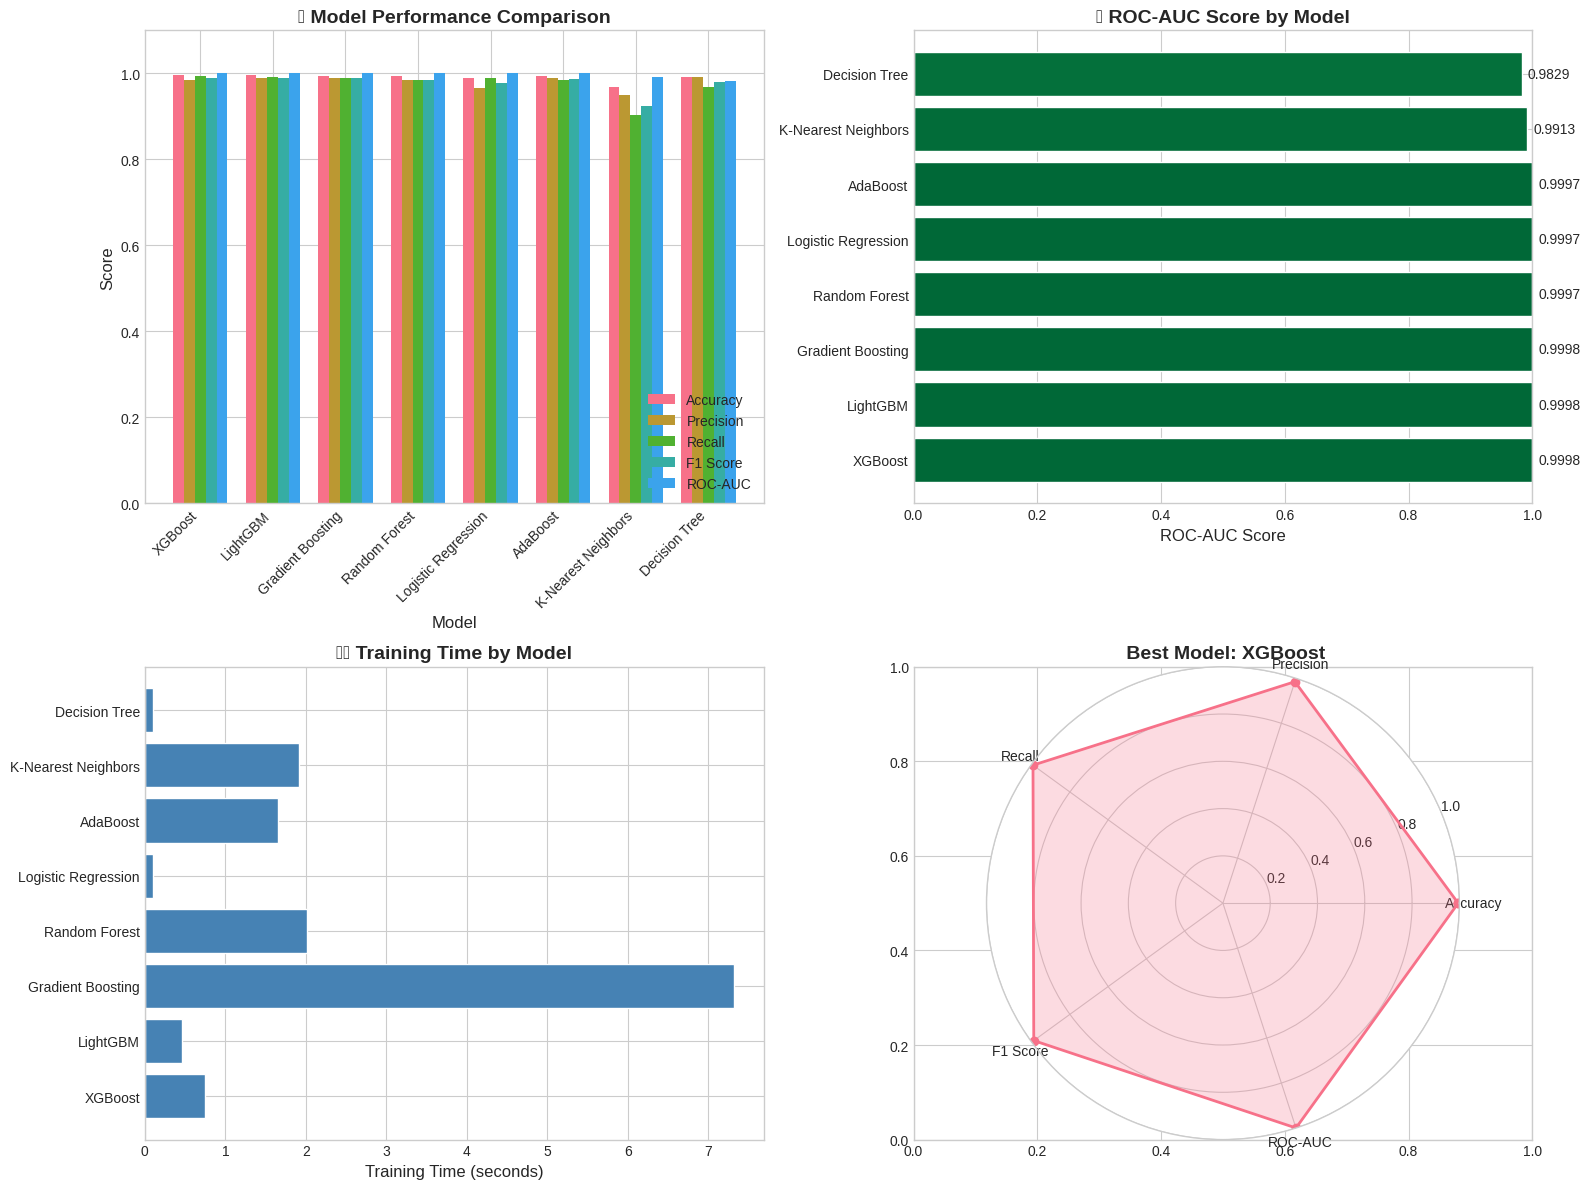


 Best Model: XGBoost with ROC-AUC: 0.9998
 Model Comparison saved as 'model_comparison.png'


In [ ]:




fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.15

for i, metric in enumerate(metrics):
    ax1.bar(x + i*width, results_df[metric], width, label=metric)

ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('📊 Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x + width * 2)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.legend(loc='lower right')
ax1.set_ylim(0, 1.1)


ax2 = axes[0, 1]
colors = plt.cm.RdYlGn(results_df['ROC-AUC'])
bars = ax2.barh(results_df['Model'], results_df['ROC-AUC'], color=colors, edgecolor='white')
ax2.set_xlabel('ROC-AUC Score', fontsize=12)
ax2.set_title('🎯 ROC-AUC Score by Model', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 1)

for bar, val in zip(bars, results_df['ROC-AUC']):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

ax3 = axes[1, 0]
ax3.barh(results_df['Model'], results_df['Training Time (s)'], color='steelblue', edgecolor='white')
ax3.set_xlabel('Training Time (seconds)', fontsize=12)
ax3.set_title('⏱️ Training Time by Model', fontsize=14, fontweight='bold')


ax4 = axes[1, 1]
best_model_name = results_df.iloc[0]['Model']
best_model_metrics = results_df.iloc[0][metrics].values

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # Complete the loop

values = list(best_model_metrics) + [best_model_metrics[0]]

ax4 = plt.subplot(2, 2, 4, projection='polar')
ax4.plot(angles, values, 'o-', linewidth=2, label=best_model_name)
ax4.fill(angles, values, alpha=0.25)
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(metrics)
ax4.set_ylim(0, 1)
ax4.set_title(f' Best Model: {best_model_name}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Best Model: {best_model_name} with ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}")
print(" Model Comparison saved as 'model_comparison.png'")


 BEST MODEL ANALYSIS: XGBoost

📋 Classification Report:
              precision    recall  f1-score   support

No Hurricane       1.00      1.00      1.00      3031
   Hurricane       0.98      0.99      0.99       858

    accuracy                           1.00      3889
   macro avg       0.99      0.99      0.99      3889
weighted avg       1.00      1.00      1.00      3889



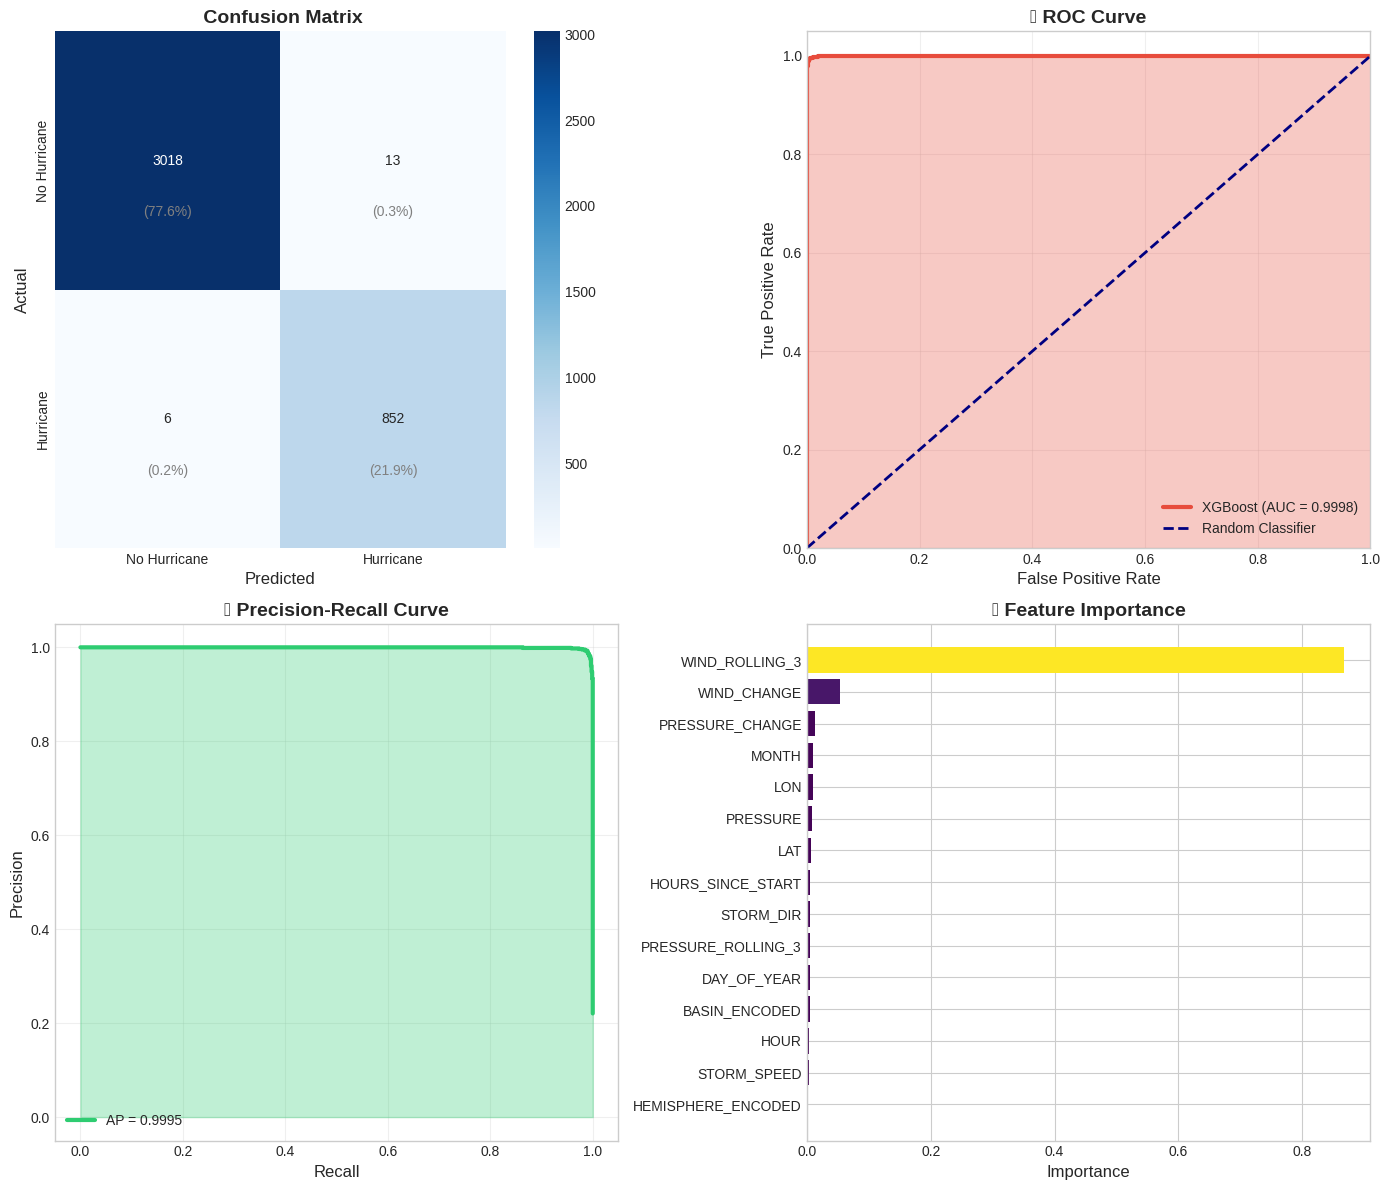

 Best Model Analysis saved as 'best_model_analysis.png'


In [ ]:

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print("=" * 60)
print(f" BEST MODEL ANALYSIS: {best_model_name}")
print("=" * 60)

y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]


print("\n📋 Classification Report:")
print(classification_report(y_test_clf, y_pred_best, target_names=['No Hurricane', 'Hurricane']))


fig, axes = plt.subplots(2, 2, figsize=(14, 12))

ax1 = axes[0, 0]
cm = confusion_matrix(y_test_clf, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['No Hurricane', 'Hurricane'],
            yticklabels=['No Hurricane', 'Hurricane'])
ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_title(' Confusion Matrix', fontsize=14, fontweight='bold')


total = cm.sum()
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / total * 100
        ax1.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)',
                 ha='center', va='center', fontsize=10, color='gray')

ax2 = axes[0, 1]
fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob_best)
roc_auc = roc_auc_score(y_test_clf, y_prob_best)

ax2.plot(fpr, tpr, color='#e74c3c', lw=3, label=f'{best_model_name} (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax2.fill_between(fpr, tpr, alpha=0.3, color='#e74c3c')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('📈 ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)


ax3 = axes[1, 0]
precision_curve, recall_curve, _ = precision_recall_curve(y_test_clf, y_prob_best)
ap_score = average_precision_score(y_test_clf, y_prob_best)

ax3.plot(recall_curve, precision_curve, color='#2ecc71', lw=3,
         label=f'AP = {ap_score:.4f}')
ax3.fill_between(recall_curve, precision_curve, alpha=0.3, color='#2ecc71')
ax3.set_xlabel('Recall', fontsize=12)
ax3.set_ylabel('Precision', fontsize=12)
ax3.set_title('📈 Precision-Recall Curve', fontsize=14, fontweight='bold')
ax3.legend(loc='lower left')
ax3.grid(True, alpha=0.3)


ax4 = axes[1, 1]
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = np.zeros(len(feature_names))

feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

colors = plt.cm.viridis(feat_importance['Importance'] / feat_importance['Importance'].max())
ax4.barh(feat_importance['Feature'], feat_importance['Importance'], color=colors)
ax4.set_xlabel('Importance', fontsize=12)
ax4.set_title('🎯 Feature Importance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('best_model_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Best Model Analysis saved as 'best_model_analysis.png'")



In [ ]:


from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 60)
print("💨 TRAINING REGRESSION MODELS (Wind Speed Prediction)")
print("=" * 60)

reg_models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42, verbose=-1)
}


reg_results = []

for name, model in reg_models.items():
    print(f"\n🔄 Training {name}...")
    start_time = time.time()

    model.fit(X_train_scaled, y_train_reg)


    y_pred = model.predict(X_test_scaled)


    train_time = time.time() - start_time
    mae = mean_absolute_error(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2 = r2_score(y_test_reg, y_pred)

    reg_results.append({
        'Model': name,
        'MAE (kts)': mae,
        'RMSE (kts)': rmse,
        'R² Score': r2,
        'Training Time (s)': train_time
    })

    print(f"  MAE: {mae:.2f} kts | RMSE: {rmse:.2f} kts | R²: {r2:.4f}")


reg_results_df = pd.DataFrame(reg_results).sort_values('R² Score', ascending=False)
print("\n" + "=" * 60)
print("📊 REGRESSION MODEL COMPARISON")
print("=" * 60)
reg_results_df


💨 TRAINING REGRESSION MODELS (Wind Speed Prediction)

🔄 Training Random Forest...
  MAE: 19.89 kts | RMSE: 25.79 kts | R²: -0.0154

🔄 Training Gradient Boosting...
  MAE: 19.87 kts | RMSE: 25.80 kts | R²: -0.0163

🔄 Training XGBoost...
  MAE: 19.96 kts | RMSE: 25.95 kts | R²: -0.0284

🔄 Training LightGBM...
  MAE: 19.87 kts | RMSE: 25.79 kts | R²: -0.0157

📊 REGRESSION MODEL COMPARISON


,Model,MAE (kts),RMSE (kts),R² Score,Training Time (s)
0,Random Forest,19.885537,25.789788,-0.015397,19.864542
3,LightGBM,19.865929,25.793511,-0.015691,0.244091
1,Gradient Boosting,19.868505,25.801427,-0.016314,8.791141
2,XGBoost,19.956618,25.954473,-0.028407,0.307344


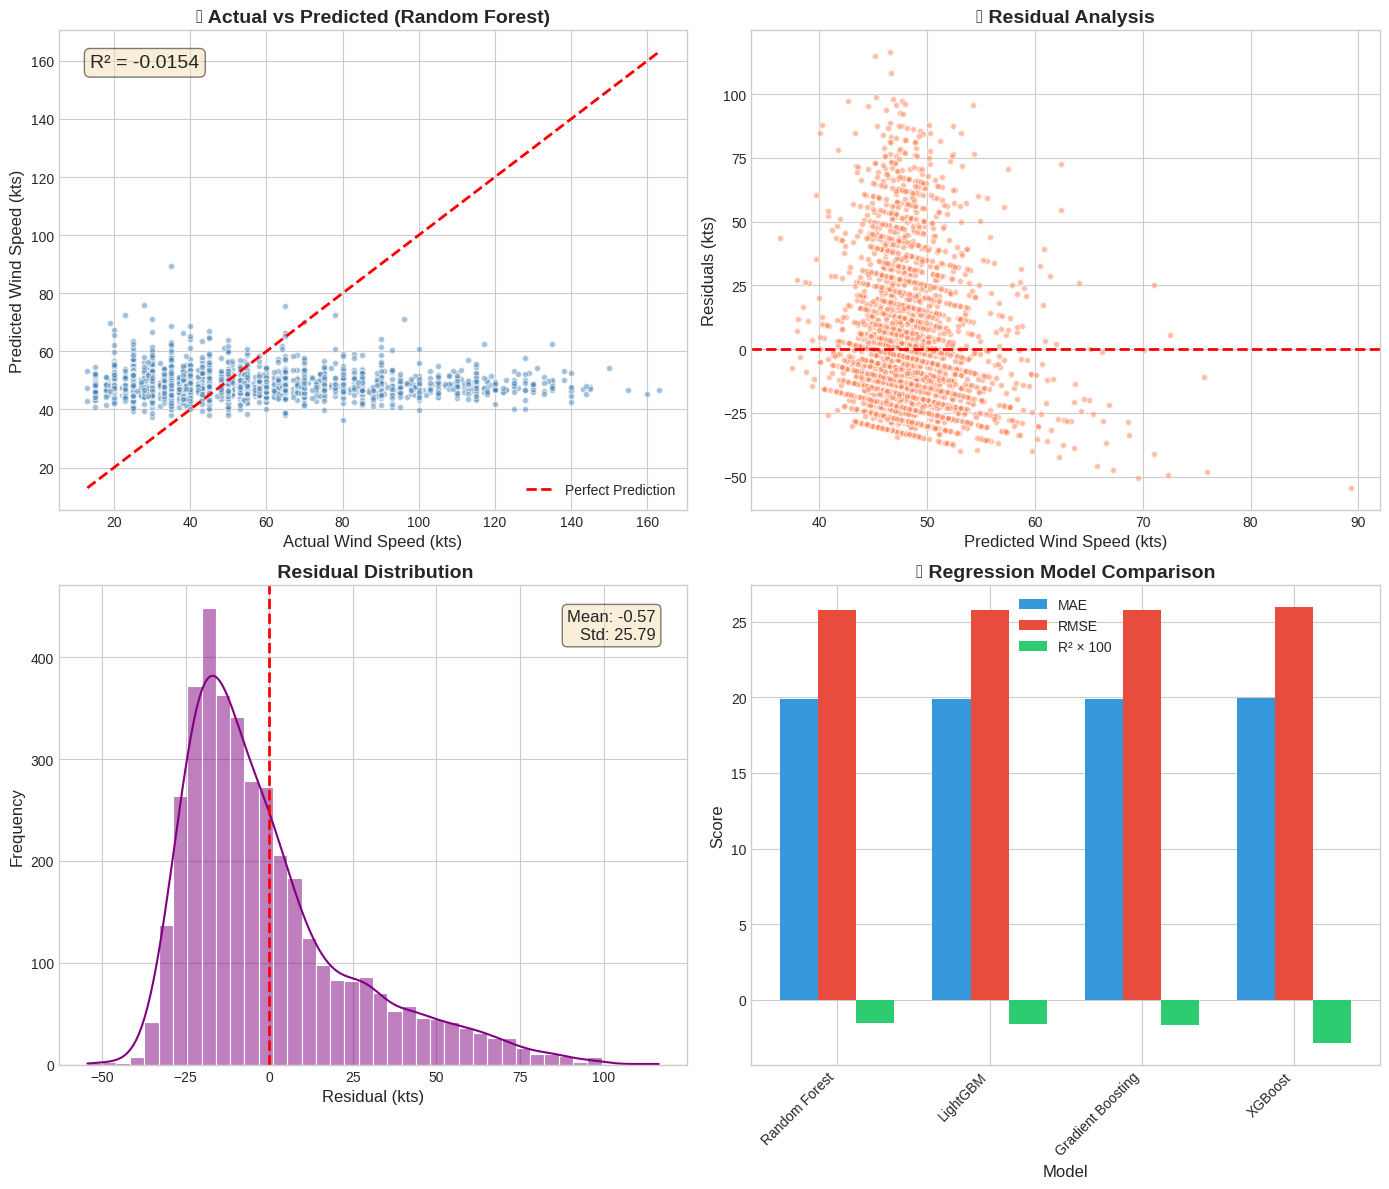


🏆 Best Regression Model: Random Forest
   MAE: 19.89 kts
   RMSE: 25.79 kts
   R²: -0.0154
✅ Regression Analysis saved as 'regression_analysis.png'


In [ ]:



best_reg_model_name = reg_results_df.iloc[0]['Model']
best_reg_model = reg_models[best_reg_model_name]
y_pred_reg = best_reg_model.predict(X_test_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

ax1 = axes[0, 0]
ax1.scatter(y_test_reg, y_pred_reg, alpha=0.5, s=20, c='steelblue', edgecolor='white')
ax1.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()],
         'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Wind Speed (kts)', fontsize=12)
ax1.set_ylabel('Predicted Wind Speed (kts)', fontsize=12)
ax1.set_title(f'📈 Actual vs Predicted ({best_reg_model_name})', fontsize=14, fontweight='bold')
ax1.legend()

r2 = r2_score(y_test_reg, y_pred_reg)
ax1.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax1.transAxes, fontsize=14,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


ax2 = axes[0, 1]
residuals = y_test_reg - y_pred_reg
ax2.scatter(y_pred_reg, residuals, alpha=0.5, s=20, c='coral', edgecolor='white')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Wind Speed (kts)', fontsize=12)
ax2.set_ylabel('Residuals (kts)', fontsize=12)
ax2.set_title('📊 Residual Analysis', fontsize=14, fontweight='bold')


ax3 = axes[1, 0]
sns.histplot(residuals, bins=40, kde=True, color='purple', ax=ax3, edgecolor='white')
ax3.axvline(x=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Residual (kts)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title(' Residual Distribution', fontsize=14, fontweight='bold')


stats_text = f'Mean: {residuals.mean():.2f}\nStd: {residuals.std():.2f}'
ax3.text(0.95, 0.95, stats_text, transform=ax3.transAxes, fontsize=12,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


ax4 = axes[1, 1]
x = np.arange(len(reg_results_df))
width = 0.25

bars1 = ax4.bar(x - width, reg_results_df['MAE (kts)'], width, label='MAE', color='#3498db')
bars2 = ax4.bar(x, reg_results_df['RMSE (kts)'], width, label='RMSE', color='#e74c3c')
bars3 = ax4.bar(x + width, reg_results_df['R² Score'] * 100, width, label='R² × 100', color='#2ecc71')

ax4.set_xlabel('Model', fontsize=12)
ax4.set_ylabel('Score', fontsize=12)
ax4.set_title('📊 Regression Model Comparison', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(reg_results_df['Model'], rotation=45, ha='right')
ax4.legend()

plt.tight_layout()
plt.savefig('regression_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n🏆 Best Regression Model: {best_reg_model_name}")
print(f"   MAE: {reg_results_df.iloc[0]['MAE (kts)']:.2f} kts")
print(f"   RMSE: {reg_results_df.iloc[0]['RMSE (kts)']:.2f} kts")
print(f"   R²: {reg_results_df.iloc[0]['R² Score']:.4f}")
print("✅ Regression Analysis saved as 'regression_analysis.png'")



 Classification (Hurricane Detection):
   Random Forest: ROC-AUC = 0.9996 ± 0.0001
   XGBoost: ROC-AUC = 0.9998 ± 0.0000
   LightGBM: ROC-AUC = 0.9999 ± 0.0001

 Regression (Wind Speed Prediction):
   Random Forest: R² = -0.0237 ± 0.0033
   XGBoost: R² = -0.0334 ± 0.0062
   LightGBM: R² = -0.0318 ± 0.0085


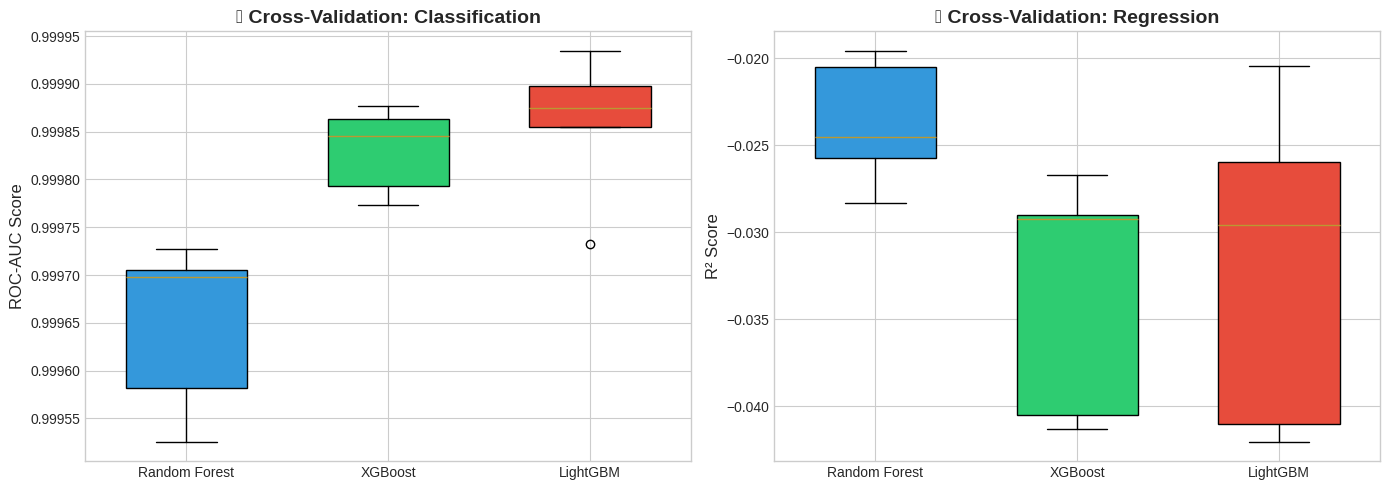

 Cross-Validation Analysis saved as 'cross_validation.png'


In [ ]:


from sklearn.model_selection import cross_val_score, StratifiedKFold



cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []


print("\n Classification (Hurricane Detection):")
for name, model in [('Random Forest', models['Random Forest']),
                     ('XGBoost', models['XGBoost']),
                     ('LightGBM', models['LightGBM'])]:
    scores = cross_val_score(model, X_train_scaled, y_train_clf, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results.append({
        'Model': name,
        'Task': 'Classification',
        'Mean Score': scores.mean(),
        'Std Score': scores.std(),
        'Scores': scores
    })
    print(f"   {name}: ROC-AUC = {scores.mean():.4f} ± {scores.std():.4f}")


print("\n Regression (Wind Speed Prediction):")
for name, model in [('Random Forest', reg_models['Random Forest']),
                     ('XGBoost', reg_models['XGBoost']),
                     ('LightGBM', reg_models['LightGBM'])]:
    scores = cross_val_score(model, X_train_scaled, y_train_reg, cv=5, scoring='r2', n_jobs=-1)
    cv_results.append({
        'Model': name,
        'Task': 'Regression',
        'Mean Score': scores.mean(),
        'Std Score': scores.std(),
        'Scores': scores
    })
    print(f"   {name}: R² = {scores.mean():.4f} ± {scores.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


ax1 = axes[0]
clf_results = [r for r in cv_results if r['Task'] == 'Classification']
positions = np.arange(len(clf_results))
bp1 = ax1.boxplot([r['Scores'] for r in clf_results], positions=positions, widths=0.6, patch_artist=True)
colors = ['#3498db', '#2ecc71', '#e74c3c']
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
ax1.set_xticks(positions)
ax1.set_xticklabels([r['Model'] for r in clf_results])
ax1.set_ylabel('ROC-AUC Score', fontsize=12)
ax1.set_title('🔄 Cross-Validation: Classification', fontsize=14, fontweight='bold')

# Regression CV
ax2 = axes[1]
reg_cv_results = [r for r in cv_results if r['Task'] == 'Regression']
positions = np.arange(len(reg_cv_results))
bp2 = ax2.boxplot([r['Scores'] for r in reg_cv_results], positions=positions, widths=0.6, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
ax2.set_xticks(positions)
ax2.set_xticklabels([r['Model'] for r in reg_cv_results])
ax2.set_ylabel('R² Score', fontsize=12)
ax2.set_title('🔄 Cross-Validation: Regression', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Cross-Validation Analysis saved as 'cross_validation.png'")


In [ ]:
# ============================================
# SAVE MODELS AND ARTIFACTS
# ============================================

import joblib
import json

print("=" * 60)
print("💾 SAVING MODELS AND ARTIFACTS")
print("=" * 60)

# Save best classification model
best_clf_model = models[best_model_name]
joblib.dump(best_clf_model, 'cyclone_classifier.pkl')
print(f"✅ Saved classification model: cyclone_classifier.pkl")

# Save best regression model
joblib.dump(best_reg_model, 'wind_predictor.pkl')
print(f"✅ Saved regression model: wind_predictor.pkl")

# Save scaler
joblib.dump(scaler, 'feature_scaler.pkl')
print(f"✅ Saved feature scaler: feature_scaler.pkl")

# Save feature names and other metadata
metadata = {
    'feature_names': feature_names,
    'best_classification_model': best_model_name,
    'best_regression_model': best_reg_model_name,
    'basin_mapping': {k: int(v) for k, v in basin_mapping.items()},
    'classification_metrics': {
        'accuracy': float(results_df.iloc[0]['Accuracy']),
        'f1_score': float(results_df.iloc[0]['F1 Score']),
        'roc_auc': float(results_df.iloc[0]['ROC-AUC'])
    },
    'regression_metrics': {
        'mae': float(reg_results_df.iloc[0]['MAE (kts)']),
        'rmse': float(reg_results_df.iloc[0]['RMSE (kts)']),
        'r2': float(reg_results_df.iloc[0]['R² Score'])
    }
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"✅ Saved metadata: model_metadata.json")

# Download files
from google.colab import files
files.download('cyclone_classifier.pkl')
files.download('wind_predictor.pkl')
files.download('feature_scaler.pkl')
files.download('model_metadata.json')

print("\n📦 All files ready for download!")


💾 SAVING MODELS AND ARTIFACTS
✅ Saved classification model: cyclone_classifier.pkl
✅ Saved regression model: wind_predictor.pkl
✅ Saved feature scaler: feature_scaler.pkl
✅ Saved metadata: model_metadata.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📦 All files ready for download!


In [ ]:
# ============================================
# GENERATE FLASK API CODE
# ============================================

flask_code = '''
# ============================================
# CYCLONE ALERT SYSTEM - Flask API
# app.py
# ============================================

from flask import Flask, request, jsonify
from flask_cors import CORS
import joblib
import numpy as np
import json

app = Flask(__name__)
CORS(app)

# Load models and artifacts
classifier = joblib.load('cyclone_classifier.pkl')
regressor = joblib.load('wind_predictor.pkl')
scaler = joblib.load('feature_scaler.pkl')

with open('model_metadata.json', 'r') as f:
    metadata = json.load(f)

feature_names = metadata['feature_names']
basin_mapping = metadata['basin_mapping']

def categorize_wind(wind):
    """Categorize cyclone based on wind speed"""
    if wind >= 137:
        return "Category 5 Hurricane", "Catastrophic damage expected"
    elif wind >= 113:
        return "Category 4 Hurricane", "Extreme damage expected"
    elif wind >= 96:
        return "Category 3 Hurricane", "Devastating damage expected"
    elif wind >= 83:
        return "Category 2 Hurricane", "Extensive damage expected"
    elif wind >= 64:
        return "Category 1 Hurricane", "Dangerous winds expected"
    elif wind >= 34:
        return "Tropical Storm", "Moderate impact expected"
    else:
        return "Tropical Depression", "Minimal impact expected"

@app.route('/api/health', methods=['GET'])
def health():
    return jsonify({'status': 'healthy', 'models_loaded': True})

@app.route('/api/predict', methods=['POST'])
def predict():
    try:
        data = request.json

        # Extract features
        features = {
            'LAT': float(data.get('latitude', 0)),
            'LON': float(data.get('longitude', 0)),
            'PRESSURE': float(data.get('pressure', 1010)),
            'MONTH': int(data.get('month', 1)),
            'HOUR': int(data.get('hour', 12)),
            'DAY_OF_YEAR': int(data.get('day_of_year', 1)),
            'BASIN_ENCODED': int(data.get('basin_code', 0)),
            'HEMISPHERE_ENCODED': 1 if float(data.get('latitude', 0)) >= 0 else 0,
            'STORM_SPEED': float(data.get('storm_speed', 10)),
            'STORM_DIR': float(data.get('storm_direction', 180)),
            'WIND_CHANGE': float(data.get('wind_change', 0)),
            'PRESSURE_CHANGE': float(data.get('pressure_change', 0)),
            'HOURS_SINCE_START': float(data.get('hours_since_start', 0)),
            'WIND_ROLLING_3': float(data.get('wind_rolling', 30)),
            'PRESSURE_ROLLING_3': float(data.get('pressure_rolling', 1005))
        }

        # Create feature array in correct order
        feature_array = np.array([[features.get(f, 0) for f in feature_names]])

        # Scale features
        feature_scaled = scaler.transform(feature_array)

        # Make predictions
        is_hurricane = int(classifier.predict(feature_scaled)[0])
        hurricane_prob = float(classifier.predict_proba(feature_scaled)[0][1])
        predicted_wind = float(regressor.predict(feature_scaled)[0])

        # Get category
        category, description = categorize_wind(predicted_wind)

        # Determine alert level
        if predicted_wind >= 96:
            alert_level = "CRITICAL"
            alert_color = "#e74c3c"
        elif predicted_wind >= 64:
            alert_level = "WARNING"
            alert_color = "#e67e22"
        elif predicted_wind >= 34:
            alert_level = "WATCH"
            alert_color = "#f1c40f"
        else:
            alert_level = "NORMAL"
            alert_color = "#2ecc71"

        return jsonify({
            'success': True,
            'prediction': {
                'is_hurricane': is_hurricane,
                'hurricane_probability': round(hurricane_prob, 4),
                'predicted_wind_speed_kts': round(predicted_wind, 1),
                'predicted_wind_speed_kmh': round(predicted_wind * 1.852, 1),
                'category': category,
                'description': description,
                'alert_level': alert_level,
                'alert_color': alert_color
            },
            'input_data': data
        })

    except Exception as e:
        return jsonify({
            'success': False,
            'error': str(e)
        }), 400

@app.route('/api/basins', methods=['GET'])
def get_basins():
    return jsonify({
        'basins': basin_mapping
    })

if __name__ == '__main__':
    app.run(debug=True, port=5000)
'''

# Save Flask API code
with open('app.py', 'w') as f:
    f.write(flask_code)

print("✅ Flask API code saved to 'app.py'")

# Requirements file
requirements = '''flask==2.3.3
flask-cors==4.0.0
numpy==1.24.3
pandas==2.0.3
scikit-learn==1.3.0
xgboost==1.7.6
lightgbm==4.0.0
joblib==1.3.2
'''

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print(" Requirements saved to 'requirements.txt'")

files.download('app.py')
files.download('requirements.txt')


✅ Flask API code saved to 'app.py'
 Requirements saved to 'requirements.txt'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:


frontend_code = '''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>🌀 Cyclone Alert System</title>
    <link href="[fonts.googleapis.com](https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&display=swap)" rel="stylesheet">
    <link rel="stylesheet" href="[unpkg.com](https://unpkg.com/leaflet@1.9.4/dist/leaflet.css)" />
    <style>
        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }

        body {
            font-family: 'Inter', sans-serif;
            background: linear-gradient(135deg, #0f0c29, #302b63, #24243e);
            min-height: 100vh;
            color: #ffffff;
        }

        .container {
            max-width: 1400px;
            margin: 0 auto;
            padding: 20px;
        }

        header {
            text-align: center;
            padding: 30px 0;
            background: rgba(255, 255, 255, 0.05);
            backdrop-filter: blur(10px);
            border-radius: 20px;
            margin-bottom: 30px;
        }

        header h1 {
            font-size: 2.5rem;
            font-weight: 700;
            background: linear-gradient(90deg, #00d2ff, #3a7bd5);
            -webkit-background-clip: text;
            -webkit-text-fill-color: transparent;
            margin-bottom: 10px;
        }

        header p {
            color: rgba(255, 255, 255, 0.7);
            font-size: 1.1rem;
        }

        .main-grid {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 30px;
        }

        @media (max-width: 900px) {
            .main-grid {
                grid-template-columns: 1fr;
            }
        }

        .card {
            background: rgba(255, 255, 255, 0.08);
            backdrop-filter: blur(10px);
            border-radius: 20px;
            padding: 25px;
            border: 1px solid rgba(255, 255, 255, 0.1);
        }

        .card h2 {
            font-size: 1.3rem;
            margin-bottom: 20px;
            display: flex;
            align-items: center;
            gap: 10px;
        }

        .form-grid {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 15px;
        }

        .form-group {
            margin-bottom: 15px;
        }

        .form-group label {
            display: block;
            margin-bottom: 8px;
            font-weight: 500;
            color: rgba(255, 255, 255, 0.8);
            font-size: 0.9rem;
        }

        .form-group input, .form-group select {
            width: 100%;
            padding: 12px 15px;
            border: 2px solid rgba(255, 255, 255, 0.1);
            border-radius: 12px;
            background: rgba(255, 255, 255, 0.05);
            color: #ffffff;
            font-size: 1rem;
            transition: all 0.3s ease;
        }

        .form-group input:focus, .form-group select:focus {
            outline: none;
            border-color: #3a7bd5;
            background: rgba(255, 255, 255, 0.1);
        }

        .form-group select option {
            background: #1a1a2e;
            color: #ffffff;
        }

        .btn {
            width: 100%;
            padding: 15px;
            border: none;
            border-radius: 12px;
            font-size: 1.1rem;
            font-weight: 600;
            cursor: pointer;
            transition: all 0.3s ease;
            margin-top: 10px;
        }

        .btn-primary {
            background: linear-gradient(90deg, #00d2ff, #3a7bd5);
            color: white;
        }

        .btn-primary:hover {
            transform: translateY(-2px);
            box-shadow: 0 10px 30px rgba(58, 123, 213, 0.4);
        }

        .result-container {
            display: none;
        }

        .result-container.active {
            display: block;
            animation: fadeIn 0.5s ease;
        }

        @keyframes fadeIn {
            from { opacity: 0; transform: translateY(20px); }
            to { opacity: 1; transform: translateY(0); }
        }

        .alert-box {
            padding: 25px;
            border-radius: 15px;
            text-align: center;
            margin-bottom: 20px;
        }

        .alert-box h3 {
            font-size: 1.8rem;
            margin-bottom: 10px;
        }

        .alert-box p {
            font-size: 1.1rem;
            opacity: 0.9;
        }

        .stats-grid {
            display: grid;
            grid-template-columns: repeat(2, 1fr);
            gap: 15px;
        }

        .stat-card {
            background: rgba(255, 255, 255, 0.05);
            padding: 20px;
            border-radius: 12px;
            text-align: center;
        }

        .stat-value {
            font-size: 2rem;
            font-weight: 700;
            color: #00d2ff;
        }

        .stat-label {
            font-size: 0.85rem;
            color: rgba(255, 255, 255, 0.6);
            margin-top: 5px;
        }

        #map {
            height: 300px;
            border-radius: 12px;
            margin-top: 20px;
        }

        .loading {
            display: none;
            text-align: center;
            padding: 30px;
        }

        .loading.active {
            display: block;
        }

        .spinner {
            width: 50px;
            height: 50px;
            border: 4px solid rgba(255, 255, 255, 0.1);
            border-top-color: #00d2ff;
            border-radius: 50%;
            animation: spin 1s linear infinite;
            margin: 0 auto 20px;
        }

        @keyframes spin {
            to { transform: rotate(360deg); }
        }

        .category-badge {
            display: inline-block;
            padding: 8px 16px;
            border-radius: 20px;
            font-weight: 600;
            margin-top: 10px;
        }

        footer {
            text-align: center;
            padding: 30px;
            margin-top: 40px;
            color: rgba(255, 255, 255, 0.5);
        }
    </style>
</head>
<body>
    <div class="container">
        <header>
            <h1> Cyclone Alert System</h1>
            <p>Advanced Weather Forecasting using Machine Learning</p>
        </header>

        <div class="main-grid">
            <div class="card">
                <h2>📍 Input Parameters</h2>
                <form id="predictionForm">
                    <div class="form-grid">
                        <div class="form-group">
                            <label>Latitude (-90 to 90)</label>
                            <input type="number" id="latitude" step="0.1" placeholder="-14.0" required>
                        </div>
                        <div class="form-group">
                            <label>Longitude (-180 to 180)</label>
                            <input type="number" id="longitude" step="0.1" placeholder="145.0" required>
                        </div>
                        <div class="form-group">
                            <label>Pressure (mb)</label>
                            <input type="number" id="pressure" step="1" placeholder="990" required>
                        </div>
                        <div class="form-group">
                            <label>Month</label>
                            <select id="month" required>
                                <option value="1">January</option>
                                <option value="2">February</option>
                                <option value="3">March</option>
                                <option value="4">April</option>
                                <option value="5">May</option>
                                <option value="6">June</option>
                                <option value="7">July</option>
                                <option value="8">August</option>
                                <option value="9">September</option>
                                <option value="10">October</option>
                                <option value="11">November</option>
                                <option value="12">December</option>
                            </select>
                        </div>
                        <div class="form-group">
                            <label>Hour (0-23)</label>
                            <input type="number" id="hour" min="0" max="23" placeholder="12" required>
                        </div>
                        <div class="form-group">
                            <label>Basin</label>
                            <select id="basin" required>
                                <option value="5">SP - South Pacific</option>
                                <option value="4">SI - South Indian</option>
                                <option value="6">WP - West Pacific</option>
                                <option value="3">NI - North Indian</option>
                                <option value="2">NA - North Atlantic</option>
                                <option value="1">EP - East Pacific</option>
                            </select>
                        </div>
                        <div class="form-group">
                            <label>Storm Speed (kts)</label>
                            <input type="number" id="storm_speed" step="1" placeholder="10" value="10">
                        </div>
                        <div class="form-group">
                            <label>Storm Direction (°)</label>
                            <input type="number" id="storm_direction" step="1" placeholder="180" value="180">
                        </div>
                    </div>
                    <button type="submit" class="btn btn-primary">🔍 Analyze Conditions</button>
                </form>
            </div>

            <div class="card">
                <h2>📊 Prediction Results</h2>

                <div class="loading" id="loading">
                    <div class="spinner"></div>
                    <p>Analyzing atmospheric conditions...</p>
                </div>

                <div class="result-container" id="results">
                    <div class="alert-box" id="alertBox">
                        <h3 id="alertTitle">--</h3>
                        <p id="alertDescription">--</p>
                        <span class="category-badge" id="categoryBadge">--</span>
                    </div>

                    <div class="stats-grid">
                        <div class="stat-card">
                            <div class="stat-value" id="probability">--%</div>
                            <div class="stat-label">Hurricane Probability</div>
                        </div>
                        <div class="stat-card">
                            <div class="stat-value" id="windSpeed">-- kts</div>
                            <div class="stat-label">Predicted Wind Speed</div>
                        </div>
                        <div class="stat-card">
                            <div class="stat-value" id="windSpeedKmh">-- km/h</div>
                            <div class="stat-label">Wind Speed (km/h)</div>
                        </div>
                        <div class="stat-card">
                            <div class="stat-value" id="alertLevel">--</div>
                            <div class="stat-label">Alert Level</div>
                        </div>
                    </div>

                    <div id="map"></div>
                </div>

                <div id="noResults" style="text-align: center; padding: 50px; color: rgba(255,255,255,0.5);">
                    <p>Enter parameters and click "Analyze" to see predictions</p>
                </div>
            </div>
        </div>

        <footer>
            <p>BTech Major Project | Cyclone Alert System using Machine Learning</p>
            <p>Built with IBTrACS Dataset | Python | Flask | XGBoost/LightGBM</p>
        </footer>
    </div>

    <script src="[unpkg.com](https://unpkg.com/leaflet@1.9.4/dist/leaflet.js)"></script>
    <script>
        let map = null;

        document.getElementById('predictionForm').addEventListener('submit', async function(e) {
            e.preventDefault();

            // Show loading
            document.getElementById('loading').classList.add('active');
            document.getElementById('results').classList.remove('active');
            document.getElementById('noResults').style.display = 'none';

            const data = {
                latitude: parseFloat(document.getElementById('latitude').value),
                longitude: parseFloat(document.getElementById('longitude').value),
                pressure: parseFloat(document.getElementById('pressure').value),
                month: parseInt(document.getElementById('month').value),
                hour: parseInt(document.getElementById('hour').value),
                day_of_year: Math.floor((parseInt(document.getElementById('month').value) - 1) * 30.44) + 15,
                basin_code: parseInt(document.getElementById('basin').value),
                storm_speed: parseFloat(document.getElementById('storm_speed').value) || 10,
                storm_direction: parseFloat(document.getElementById('storm_direction').value) || 180,
                wind_change: 0,
                pressure_change: 0,
                hours_since_start: 24,
                wind_rolling: 35,
                pressure_rolling: parseFloat(document.getElementById('pressure').value)
            };

            try {
                // Replace with your actual API URL
                const response = await fetch('[localhost](http://localhost:5000/api/predict)', {
                    method: 'POST',
                    headers: { 'Content-Type': 'application/json' },
                    body: JSON.stringify(data)
                });

                const result = await response.json();

                if (result.success) {
                    displayResults(result.prediction, data);
                } else {
                    alert('Error: ' + result.error);
                }
            } catch (error) {
                // Demo mode - show sample results
                const demoResult = {
                    hurricane_probability: data.pressure < 990 ? 0.85 : 0.25,
                    predicted_wind_speed_kts: Math.max(20, 180 - data.pressure * 0.15),
                    predicted_wind_speed_kmh: Math.max(20, 180 - data.pressure * 0.15) * 1.852,
                    category: data.pressure < 970 ? "Category 3 Hurricane" : data.pressure < 990 ? "Category 1 Hurricane" : "Tropical Storm",
                    description: data.pressure < 970 ? "Devastating damage expected" : "Moderate impact expected",
                    alert_level: data.pressure < 970 ? "CRITICAL" : data.pressure < 990 ? "WARNING" : "WATCH",
                    alert_color: data.pressure < 970 ? "#e74c3c" : data.pressure < 990 ? "#e67e22" : "#f1c40f"
                };
                displayResults(demoResult, data);
            }

            document.getElementById('loading').classList.remove('active');
        });

        function displayResults(prediction, inputData) {
            document.getElementById('results').classList.add('active');

            // Update alert box
            const alertBox = document.getElementById('alertBox');
            alertBox.style.backgroundColor = prediction.alert_color;
            document.getElementById('alertTitle').textContent =
                prediction.alert_level === 'CRITICAL' ? '⚠️ CYCLONE ALERT!' :
                prediction.alert_level === 'WARNING' ? '🌀 HURRICANE WARNING' :
                prediction.alert_level === 'WATCH' ? '👁️ STORM WATCH' : '✅ CONDITIONS NORMAL';
            document.getElementById('alertDescription').textContent = prediction.description;
            document.getElementById('categoryBadge').textContent = prediction.category;
            document.getElementById('categoryBadge').style.backgroundColor = 'rgba(0,0,0,0.3)';

            // Update stats
            document.getElementById('probability').textContent =
                (prediction.hurricane_probability * 100).toFixed(1) + '%';
            document.getElementById('windSpeed').textContent =
                prediction.predicted_wind_speed_kts.toFixed(0) + ' kts';
            document.getElementById('windSpeedKmh').textContent =
                prediction.predicted_wind_speed_kmh.toFixed(0) + ' km/h';
            document.getElementById('alertLevel').textContent = prediction.alert_level;

            // Update map
            if (map) {
                map.remove();
            }

            map = L.map('map').setView([inputData.latitude, inputData.longitude], 5);
            L.tileLayer('[{s}.basemaps.cartocdn.com](https://{s}.basemaps.cartocdn.com/dark_all/{z}/{x}/{y}{r}.png)', {
                attribution: '© OpenStreetMap contributors'
            }).addTo(map);

            // Add marker
            const markerColor = prediction.alert_level === 'CRITICAL' ? 'red' :
                               prediction.alert_level === 'WARNING' ? 'orange' : 'yellow';

            L.circleMarker([inputData.latitude, inputData.longitude], {
                radius: 15,
                fillColor: markerColor,
                color: '#fff',
                weight: 2,
                opacity: 1,
                fillOpacity: 0.8
            }).addTo(map)
            .bindPopup(`<b>${prediction.category}</b><br>Wind: ${prediction.predicted_wind_speed_kts.toFixed(0)} kts`);
        }
    </script>
</body>
</html>
'''

# Save frontend code
with open('index.html', 'w') as f:
    f.write(frontend_code)

print("✅ Frontend code saved to 'index.html'")
files.download('index.html')


✅ Frontend code saved to 'index.html'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>